# **TUGAS BESAR KELOMPOK 8**



---


## **Informasi Dataset**

Dataset yang digunakan adalah **Green Logistics: Carbon Footprint for E-Commerce**. Dataset ini dirancang untuk mensimulasikan sistem pelacakan emisi karbon pada aktivitas logistik dengan mempertimbangkan faktor kendaraan, jarak tempuh, berat paket, dan kondisi lalu lintas.

| Attribute | Description |
|------------|------------|
| Transaction_ID | Identitas unik setiap transaksi atau pengiriman. |
| Date | Tanggal pengiriman dilakukan. |
| Origin_Facility | Gudang atau fasilitas asal pengiriman. |
| Destination_City | Kota tujuan pengiriman. |
| Vehicle_Type | Jenis kendaraan yang digunakan untuk pengiriman, seperti Diesel Van, Electric Van, Cargo Bike, atau Drone. |
| Route_Type | Kategori rute pengiriman, misalnya Urban Last Mile atau Inter-City. |
| Distance_KM | Jarak tempuh pengiriman dalam kilometer. |
| Package_Weight_KG | Berat paket yang dikirim dalam kilogram. |
| Traffic_Conditions | Kondisi lalu lintas selama pengiriman, seperti Low, Medium, High, atau Severe. |
| Carbon_Emission_kgCO2e | Total emisi karbon yang dihasilkan selama pengiriman (variabel target). |
| Is_Eco_Friendly | Indikator kendaraan ramah lingkungan, dimana 1 menunjukkan kendaraan ramah lingkungan (EV, Cargo Bike, Drone) dan 0 menunjukkan kendaraan berbahan bakar fosil. |



In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv("ecommerce_logistics_carbon_emissions_v1.csv")
df.head()

,Transaction_ID,Date,Origin_Facility,Destination_City,Vehicle_Type,Route_Type,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e,Is_Eco_Friendly
0,TRX-F775953B,2025-02-18,Jakarta Fulfillment Center,Waynehaven,Electric Van (EV),Mixed Route,80.4,15.6,Normal,4.100,1
1,TRX-B4C50003,2025-09-11,Jakarta Fulfillment Center,East Patriciaside,Diesel Van (Euro 6),Mixed Route,135.3,18.8,Low,23.130,0
2,TRX-F7C71F39,2025-06-15,Semarang Depot,Pottershire,Drone Delivery,Urban Last Mile,9.0,25.4,Normal,0.091,1
3,TRX-A60E6AAA,2025-06-23,Semarang Depot,North Christina,Drone Delivery,Urban Last Mile,11.8,13.5,High,0.101,1
4,TRX-D0CFAF87,2025-02-15,Jakarta Fulfillment Center,Lisamouth,Heavy Truck,Inter-City,156.5,1792.6,Normal,128.004,0


## 1. Data Exploration

### 1.1 Periksa jumlah baris dan kolom

In [49]:
print(f'Baris: {df.shape[0]}')
print(f'Kolom: {df.shape[1]}')

Baris: 12000
Kolom: 11


### 1.2 Periksa informasi dataset

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction_ID          12000 non-null  object 
 1   Date                    12000 non-null  object 
 2   Origin_Facility         12000 non-null  object 
 3   Destination_City        12000 non-null  object 
 4   Vehicle_Type            12000 non-null  object 
 5   Route_Type              12000 non-null  object 
 6   Distance_KM             12000 non-null  float64
 7   Package_Weight_KG       12000 non-null  float64
 8   Traffic_Conditions      12000 non-null  object 
 9   Carbon_Emission_kgCO2e  12000 non-null  float64
 10  Is_Eco_Friendly         12000 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 1.0+ MB


### 1.3 Periksa ringkasan statistik pada kolom numerik

In [51]:
df.describe()

,Distance_KM,Package_Weight_KG,Carbon_Emission_kgCO2e,Is_Eco_Friendly
count,12000.000000,12000.000000,12000.000000,12000.000000
mean,102.851408,396.355458,71.994260,0.427000
std,163.538763,1064.274964,180.524361,0.494663
min,1.000000,0.500000,0.000000,0.000000
25%,11.600000,8.800000,0.093000,0.000000
50%,37.500000,17.300000,4.150000,0.000000
75%,114.600000,26.100000,24.091250,1.000000
max,799.900000,4985.500000,1280.173000,1.000000


### 1.4 Periksa baris duplikat

In [52]:
df.duplicated().sum()

np.int64(0)

### 1.5 Periksa nilai kosong

In [53]:
df.isna().sum()

Transaction_ID            0
Date                      0
Origin_Facility           0
Destination_City          0
Vehicle_Type              0
Route_Type                0
Distance_KM               0
Package_Weight_KG         0
Traffic_Conditions        0
Carbon_Emission_kgCO2e    0
Is_Eco_Friendly           0
dtype: int64

### 1.6 Periksa nilai unik 

In [54]:
# Menampilkan jumlah nilai uni pada setiap kolom
df.nunique()

Transaction_ID            12000
Date                        366
Origin_Facility               6
Destination_City           8910
Vehicle_Type                  7
Route_Type                    4
Distance_KM                2882
Package_Weight_KG          1940
Traffic_Conditions            4
Carbon_Emission_kgCO2e     7694
Is_Eco_Friendly               2
dtype: int64

In [55]:
# Menampilkan nilai unik pada kolom kategorikal

for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].unique())


Transaction_ID:
['TRX-F775953B' 'TRX-B4C50003' 'TRX-F7C71F39' ... 'TRX-6E74CEA4'
 'TRX-6666F18C' 'TRX-FBE1FF3C']

Date:
['2025-02-18' '2025-09-11' '2025-06-15' '2025-06-23' '2025-02-15'
 '2025-01-07' '2025-06-06' '2025-11-11' '2025-09-07' '2025-07-30'
 '2025-12-09' '2025-05-24' '2025-12-15' '2025-07-18' '2025-04-13'
 '2025-07-21' '2025-11-16' '2025-10-08' '2025-12-12' '2025-09-03'
 '2025-04-10' '2025-08-03' '2025-06-20' '2025-01-06' '2025-04-14'
 '2025-11-12' '2025-11-21' '2025-06-22' '2025-06-17' '2025-12-19'
 '2025-10-20' '2025-02-07' '2025-08-27' '2025-01-20' '2025-03-04'
 '2025-10-28' '2025-08-02' '2025-08-23' '2026-01-01' '2025-08-18'
 '2025-05-29' '2025-01-22' '2025-01-12' '2025-06-26' '2025-07-03'
 '2025-03-24' '2025-07-09' '2025-11-04' '2025-03-16' '2025-06-12'
 '2025-03-11' '2025-04-24' '2025-11-08' '2025-04-02' '2025-06-10'
 '2025-11-06' '2025-04-21' '2025-04-17' '2025-02-09' '2025-10-24'
 '2025-09-10' '2025-11-24' '2025-12-05' '2025-01-25' '2025-02-08'
 '2025-08-26' '2025-0

## 2. Data Preparation

In [56]:
df_clean = df.copy()
df_clean.head()

,Transaction_ID,Date,Origin_Facility,Destination_City,Vehicle_Type,Route_Type,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e,Is_Eco_Friendly
0,TRX-F775953B,2025-02-18,Jakarta Fulfillment Center,Waynehaven,Electric Van (EV),Mixed Route,80.4,15.6,Normal,4.100,1
1,TRX-B4C50003,2025-09-11,Jakarta Fulfillment Center,East Patriciaside,Diesel Van (Euro 6),Mixed Route,135.3,18.8,Low,23.130,0
2,TRX-F7C71F39,2025-06-15,Semarang Depot,Pottershire,Drone Delivery,Urban Last Mile,9.0,25.4,Normal,0.091,1
3,TRX-A60E6AAA,2025-06-23,Semarang Depot,North Christina,Drone Delivery,Urban Last Mile,11.8,13.5,High,0.101,1
4,TRX-D0CFAF87,2025-02-15,Jakarta Fulfillment Center,Lisamouth,Heavy Truck,Inter-City,156.5,1792.6,Normal,128.004,0


### 2.1 Outlier Handling

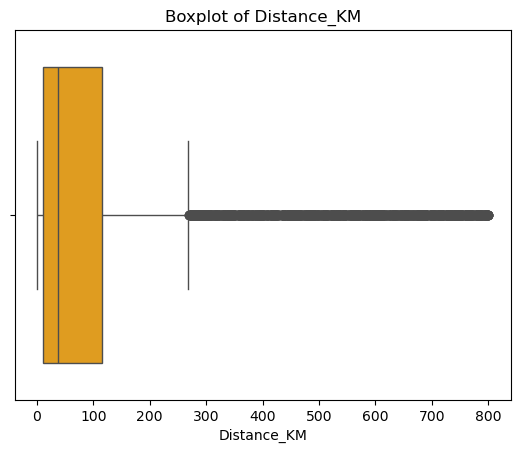

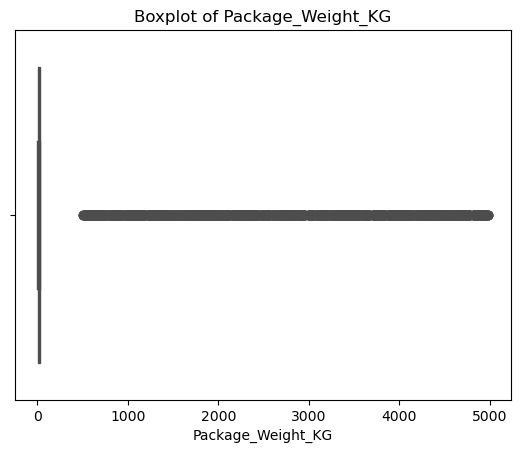

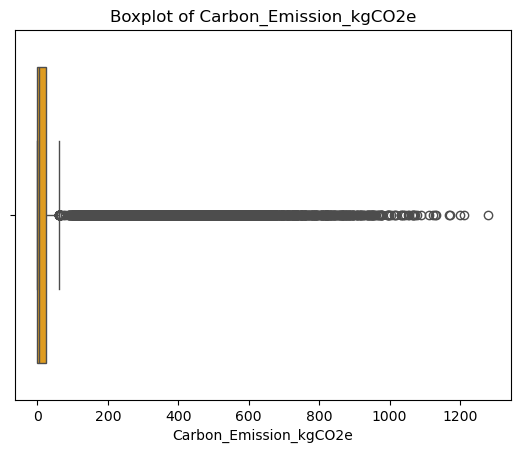

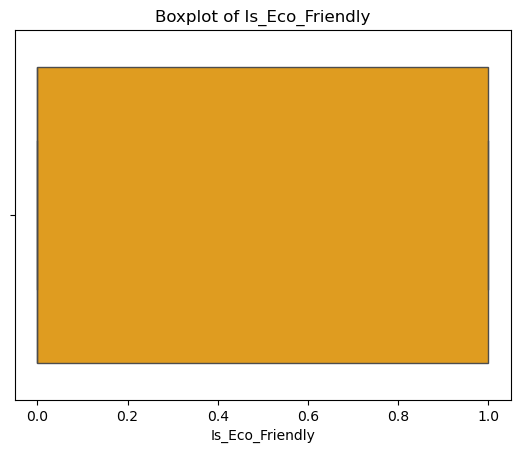

In [57]:
for col in df_clean.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [58]:
# Jumlah dan persentase outlier 

for col in df_clean.select_dtypes(include='number'):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"Jumlah outlier {col}: {len(outliers)}")
    print(f"Persentase outlier {col}: {len(outliers)/len(df)*100:.2f}%\n")



Jumlah outlier Distance_KM: 1263
Persentase outlier Distance_KM: 10.53%

Jumlah outlier Package_Weight_KG: 1679
Persentase outlier Package_Weight_KG: 13.99%

Jumlah outlier Carbon_Emission_kgCO2e: 1702
Persentase outlier Carbon_Emission_kgCO2e: 14.18%

Jumlah outlier Is_Eco_Friendly: 0
Persentase outlier Is_Eco_Friendly: 0.00%



In [59]:
# Hapus Outlier
for col in df_clean.select_dtypes(include='number').columns:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
        
    batas_atas = Q3 + 1.5 * IQR
    batas_bawah = Q1 - 1.5 * IQR
        
        
    df_clean = df_clean[(df[col] >= batas_bawah) & (df[col] <= batas_atas)]
    
print(f'Jumlah baris setelah hapus outlier adalah {df_clean.shape[0]}')

Jumlah baris setelah hapus outlier adalah 9396


C:\Users\dinar\AppData\Local\Temp\ipykernel_13360\3472242461.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[(df[col] >= batas_bawah) & (df[col] <= batas_atas)]
C:\Users\dinar\AppData\Local\Temp\ipykernel_13360\3472242461.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[(df[col] >= batas_bawah) & (df[col] <= batas_atas)]
C:\Users\dinar\AppData\Local\Temp\ipykernel_13360\3472242461.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[(df[col] >= batas_bawah) & (df[col] <= batas_atas)]


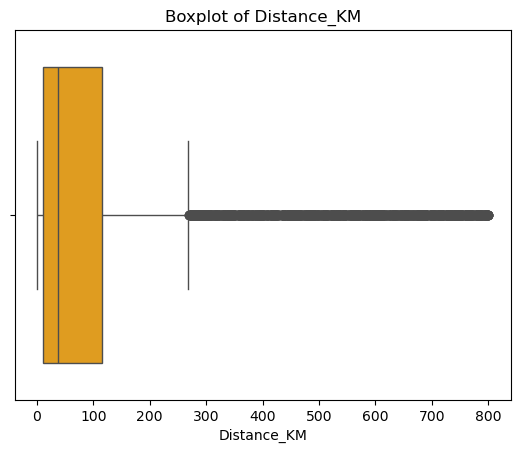

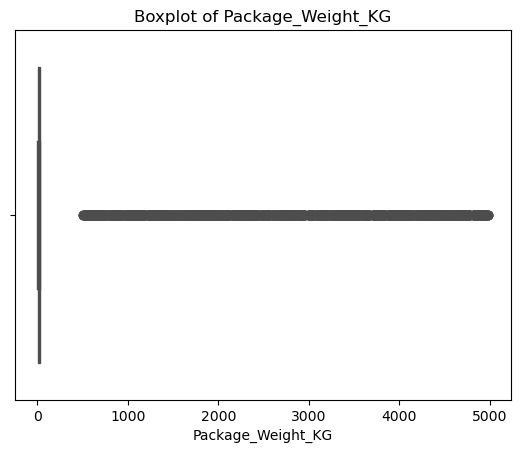

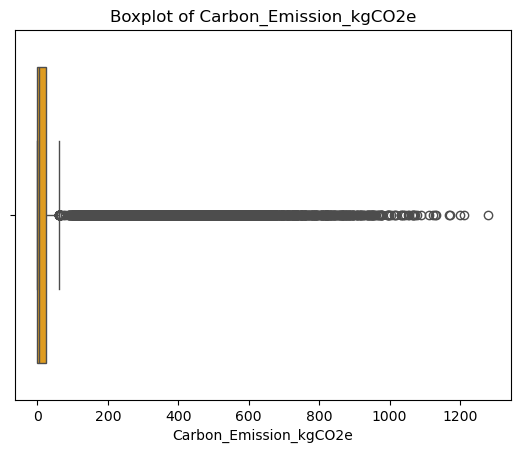

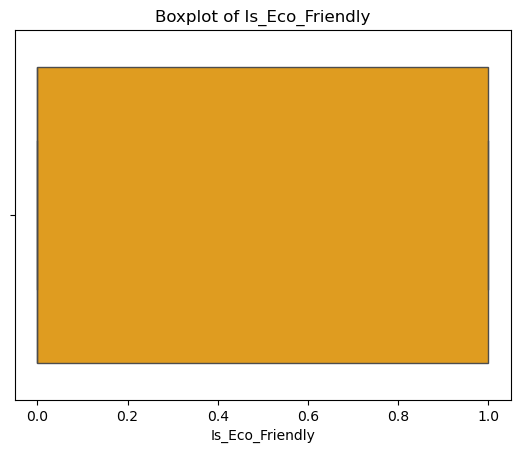

In [60]:
# Visualisasi setelah membersihkan outlier

for col in df_clean.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.show()

### 2.2 Hapus fitur yang tidak digunakan

In [61]:
df_clean.drop(columns=['Transaction_ID', 'Date', 'Destination_City', 'Is_Eco_Friendly'], inplace=True)
df_clean.head()

,Origin_Facility,Vehicle_Type,Route_Type,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e
0,Jakarta Fulfillment Center,Electric Van (EV),Mixed Route,80.4,15.6,Normal,4.100
1,Jakarta Fulfillment Center,Diesel Van (Euro 6),Mixed Route,135.3,18.8,Low,23.130
2,Semarang Depot,Drone Delivery,Urban Last Mile,9.0,25.4,Normal,0.091
3,Semarang Depot,Drone Delivery,Urban Last Mile,11.8,13.5,High,0.101
5,Jakarta Fulfillment Center,Motorcycle (Courier),Inter-District,5.4,26.8,High,0.715


### 2.3 Mengubah tipe data

In [62]:
df_clean.dtypes

Origin_Facility            object
Vehicle_Type               object
Route_Type                 object
Distance_KM               float64
Package_Weight_KG         float64
Traffic_Conditions         object
Carbon_Emission_kgCO2e    float64
dtype: object

In [63]:
# Label encoding untuk fitur 'Route_Type'

traffic_map = {
    'Low': 0,
    'Normal': 1,
    'High': 2,
    'Severe Congestion': 3
}
df_clean['Traffic_Conditions'] = df_clean['Traffic_Conditions'].map(traffic_map)

In [64]:
# One hot encoding untuk kolom Origin_Facility, Vehicle_Type, dan Route_Type

df_clean = pd.get_dummies(df_clean, columns=['Origin_Facility',	'Vehicle_Type','Route_Type'])
df_clean.head()

,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e,Origin_Facility_Bandung Hub,Origin_Facility_Jakarta Fulfillment Center,Origin_Facility_Makassar Port,Origin_Facility_Medan Distribution,Origin_Facility_Semarang Depot,Origin_Facility_Surabaya Warehouse,Vehicle_Type_Cargo Bicycle,Vehicle_Type_Diesel Van (Euro 4),Vehicle_Type_Diesel Van (Euro 6),Vehicle_Type_Drone Delivery,Vehicle_Type_Electric Van (EV),Vehicle_Type_Motorcycle (Courier),Route_Type_Inter-District,Route_Type_Mixed Route,Route_Type_Urban Last Mile
0,80.4,15.6,1,4.100,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False
1,135.3,18.8,0,23.130,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,9.0,25.4,1,0.091,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
3,11.8,13.5,2,0.101,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
5,5.4,26.8,2,0.715,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False


## 3. Modeling & Evaluating

## Random Forest Regressor (Supervised Learning)
---

### 3.1 Memisahkan variabel dependen dan independen

In [65]:
x = df_clean.drop(columns=['Carbon_Emission_kgCO2e'])
y = df_clean['Carbon_Emission_kgCO2e']

### 3.2 Split data latih dan data uji

In [66]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### 3.3 Standarisasi Data

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standarisasi Variabel Dependen
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

### 3.4 Latih model

In [68]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train_scaled, y_train)
y_pred = rf_model.predict(x_test_scaled)

### 3.5 Evaluasi model

In [69]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.23980268889311027
MSE : 0.23729555505437855
RMSE: 0.4871299159920057
R²  : 0.9956501187128208


### 3.6 Model Tuning

In [70]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

t=2026-06-15T23:02:29+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=2cb325d349ae clientid=1fbd1493be5030c7135fb2a984f0665f
t=2026-06-15T23:02:29+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=0018be6fb9e6 err="write tcp [2404:c0:a302:40a6:4d8a:cb70:c11f:bcbf]:49677->[2600:1f16:d83:1201:5854:db5f:dc55:ef83]:443: wsasend: An existing connection was forcibly closed by the remote host."
t=2026-06-15T23:08:49+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=4900c13e313d clientid=1fbd1493be5030c7135fb2a984f0665f
t=2026-06-15T23:08:49+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=0018be6fb9e6 err="session closed"


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best Score: 0.995154695255334


### 3.6 Evaluasi Model After Tuning

In [71]:
rf_model = RandomForestRegressor(max_depth= 10, min_samples_leaf= 2, min_samples_split= 2, n_estimators= 300)
rf_model.fit(x_train_scaled, y_train)

y_pred = rf_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.23570122161517426
MSE : 0.21970911331877366
RMSE: 0.468731387170492
R²  : 0.9959724969967134


## KMeans Clustering (Unsupervised Learning)
---

### 3.7 Standarisasi Data

In [72]:
df_clean.head()

,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e,Origin_Facility_Bandung Hub,Origin_Facility_Jakarta Fulfillment Center,Origin_Facility_Makassar Port,Origin_Facility_Medan Distribution,Origin_Facility_Semarang Depot,Origin_Facility_Surabaya Warehouse,Vehicle_Type_Cargo Bicycle,Vehicle_Type_Diesel Van (Euro 4),Vehicle_Type_Diesel Van (Euro 6),Vehicle_Type_Drone Delivery,Vehicle_Type_Electric Van (EV),Vehicle_Type_Motorcycle (Courier),Route_Type_Inter-District,Route_Type_Mixed Route,Route_Type_Urban Last Mile
0,80.4,15.6,1,4.100,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False
1,135.3,18.8,0,23.130,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,9.0,25.4,1,0.091,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
3,11.8,13.5,2,0.101,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
5,5.4,26.8,2,0.715,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False


In [73]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df_clean)

In [74]:
# Menggunakan PCA untuk mereduksi fitur numerik menjadi 2 dimensi
   
from sklearn.decomposition import PCA  

pca = PCA(n_components=2)
x_pca = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=x_pca, columns=['PCA1', 'PCA2'])

### 3.4 Menentukan Jumlah Cluster yang Optimal

In [75]:
from sklearn.cluster import KMeans  

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit_predict(df_pca) 
    wcss.append(kmeans.inertia_)

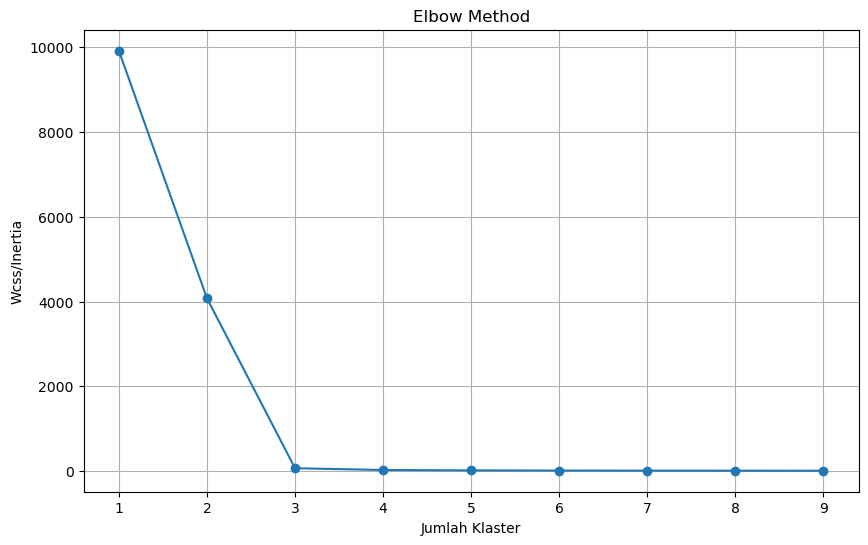

In [76]:
# Visualisasi Elbowmethod

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel('Jumlah Klaster')
plt.ylabel('Wcss/Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

### 3.5 Melatih Model

In [77]:
model_kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = model_kmeans.fit_predict(df_pca)
df_pca_label= df_pca.copy()
df_pca_label['Cluster_Label'] = model_kmeans.labels_

### 3.5 Evaluasi Model (sebelum tuning)

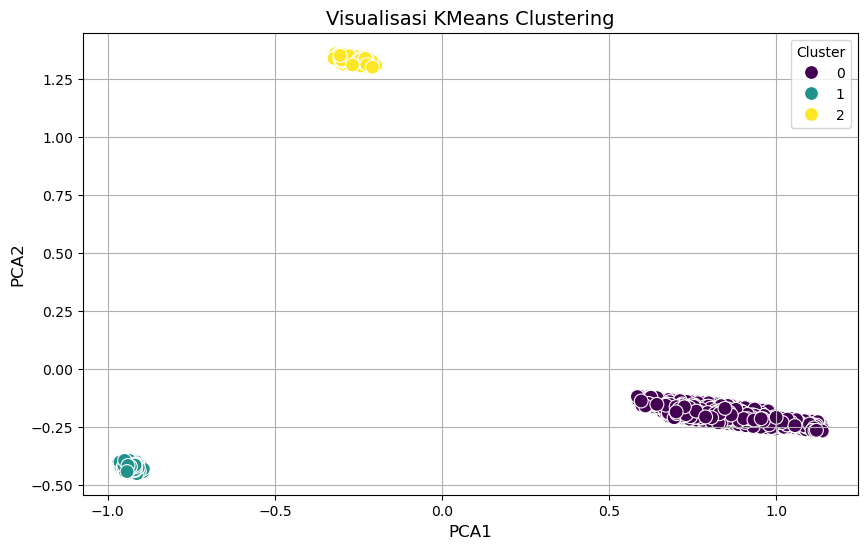

In [78]:
# Visualisasi cluster
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Label', data=df_pca_label, palette='viridis', s=100) 
plt.title('Visualisasi KMeans Clustering', fontsize=14) 
plt.xlabel('PCA1', fontsize=12) 
plt.ylabel('PCA2', fontsize=12) 
plt.legend(title='Cluster') 
plt.grid(True) 
plt.show()

In [79]:
# Menghitung sihouette score

from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(df_pca, model_kmeans.labels_)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.95538445182836


### 3.7 Model Tuning

In [80]:
# Implemetas Grid Search
from sklearn.model_selection import GridSearchCV

# Menentukan Parameter
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10],
    'init': ['k-means++', 'random'],
    'n_init' :[10],
    'max_iter': [300],
    'random_state': [42]
}

In [81]:
# Inisialisasi GridSearchCV
kmeans = KMeans()
grid_search = GridSearchCV(estimator=kmeans, param_grid=param_grid, scoring=None, cv=3)

In [82]:
# Fit model dengan data yang dipakai sebelum tuning
grid_search.fit(df_pca)

,estimator,KMeans()
,param_grid,"{'init': ['k-means++', 'random'], 'max_iter': [300], 'n_clusters': [2, 3, ...], 'n_init': [10], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_clusters,10


### 3.8 Evaluasi Model (setelah tuning)

In [83]:
best_score = -1
best_params = None

for params in grid_search.cv_results_['params']:
    model = KMeans(**params)
    cluster_labels = model.fit_predict(df_pca)
    score = silhouette_score(df_pca, cluster_labels)

    if score > best_score:
        best_score = score
        best_params = params

t=2026-06-15T23:28:16+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=0018be6fb9e6 err="read tcp [2404:c0:a302:40a6:4d8a:cb70:c11f:bcbf]:49667->[2600:1f16:d83:1202:91bb:8f00:b395:914e]:443: wsarecv: An existing connection was forcibly closed by the remote host."
t=2026-06-15T23:28:16+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=189aa14ea00b clientid=1fbd1493be5030c7135fb2a984f0665f


In [84]:
print("Best Silhouette Score:", best_score)
print("Best Parameters:", best_params)

Best Silhouette Score: 0.95538445182836
Best Parameters: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3, 'n_init': 10, 'random_state': 42}


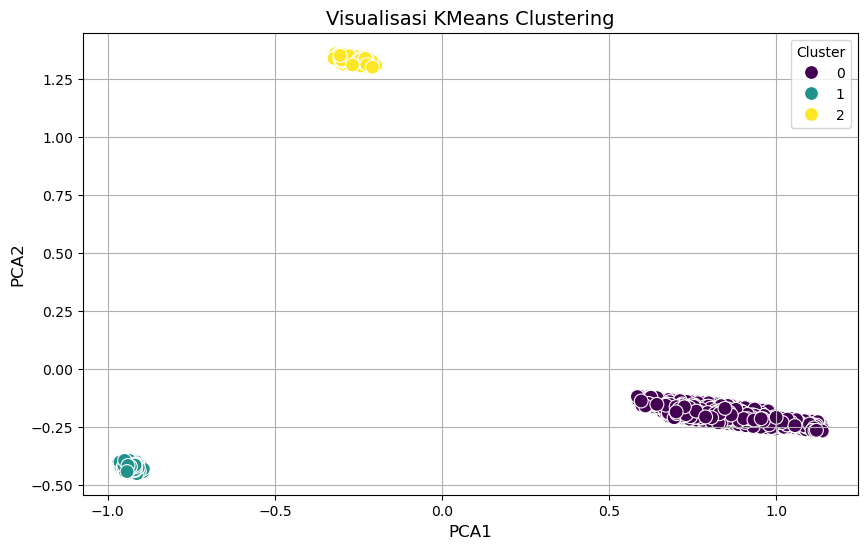

In [85]:
model_kmeans = KMeans(init= 'k-means++', max_iter= 300, n_clusters= 3, n_init= 10, random_state= 42)
cluster_labels = model_kmeans.fit_predict(df_pca)
df_pca['Cluster_Label'] = model_kmeans.labels_

# Visualisasi cluster
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Label', data=df_pca, palette='viridis', s=100) 
plt.title('Visualisasi KMeans Clustering', fontsize=14) 
plt.xlabel('PCA1', fontsize=12) 
plt.ylabel('PCA2', fontsize=12) 
plt.legend(title='Cluster') 
plt.grid(True) 
plt.show()

In [86]:
silhouette_avg = silhouette_score(df_pca, model_kmeans.labels_)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.9611370210696085


## 4. Deployment

### 4.1 Save model

In [87]:
from joblib import dump
dump(rf_model, 'randomforest.pkl')
dump(model_kmeans, 'kmeans.pkl')

['kmeans.pkl']

### 4.2 Konfigurasi token

In [88]:
!ngrok config add-authtoken 3Dq5dR2tw2MoZRTlSrbIYB8plQd_2ZtZ7NN9Qj3ZbxsLp4exw

Authtoken saved to configuration file: C:\Users\dinar\AppData\Local\ngrok\ngrok.yml


### 4.3 Konfigurasi Streamlit

In [89]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler 
import seaborn as sns
from sklearn.model_selection import train_test_split

st.set_page_config(
    page_title="Emisi Karbon",
    page_icon= "🚗"
)
st.title("Emisi Karbon Pada Aktivitas Logistik E-commerce")
st.write("Dashboard ini berisi sebaran data dan alat prediksi jumlah emisi karbon yang dihasilkan aktivitas logistik E-Commerce")


# Load Model Random Forest yang sudah dilatih 
model = joblib.load("randomforest.pkl")

# Load dataset
df = pd.read_csv('ecommerce_logistics_carbon_emissions_v1.csv')

# Hapus kolom yang tidak relevan
df.drop(columns=['Transaction_ID', 'Date', 'Destination_City', 'Is_Eco_Friendly'], inplace=True)

# Handle Outlier
for col in df.select_dtypes(include='number').columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
        
    batas_atas = Q3 + 1.5 * IQR
    batas_bawah = Q1 - 1.5 * IQR
        
        
    df = df[(df[col] >= batas_bawah) & (df[col] <= batas_atas)]

# Ambil nilai unik pada kolom Origin_Facility, Vehicle_Type, Route_Type
origin_options = sorted(df['Origin_Facility'].unique())
vehicle_options = sorted(df['Vehicle_Type'].unique())
route_options = sorted(df['Route_Type'].unique())
        
# Mengubah tipe data pada kolom akategori
traffic_map = {
    'Low': 0,
    'Normal': 1,
    'High': 2,
    'Severe Congestion': 3
}
df['Traffic_Conditions'] = df['Traffic_Conditions'].map(traffic_map)

df = pd.get_dummies(df, columns=['Origin_Facility', 'Vehicle_Type', 'Route_Type'])
   
# Pisahkan variabel dependen dan independen
x = df.drop(columns=['Carbon_Emission_kgCO2e'])
y = df['Carbon_Emission_kgCO2e']

# Pisah data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Standarisasi Variabel Dependen
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

# Buat prediksi menggunakan model yang sudah dilatih
y_pred = model.predict(x_test_scaled)

# itung evaluasi model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
    
tab1, tab2 = st.tabs([
    "Prediksi",
    "Sebaran Data"
])

with tab1:
    st.header('Prediksi Jumlah Emisi Karbon')
    
    st.subheader("Evaluasi Model")
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric(label="MAE", value=f"{mae:.2f}")
    with col2:
        st.metric(label="MSE", value=f"{mse:.2f}")
    with col3:
        st.metric(label="RMSE", value=f"{rmse:.2f}")
    with col4:
        st.metric(label="R2", value=f"{r2:.3f}") 

    original_data = pd.read_csv("ecommerce_logistics_carbon_emissions_v1.csv")
    original_data = original_data.dropna(subset=['Transaction_ID', 'Date', 'Destination_City', 'Is_Eco_Friendly'])

    st.subheader("Form Prediksi")
    st.write("Isi semua kolom pada form di bawah ini dan tekan tombol 'Prediksi' intuk melihat hasil predisi jumlah emisi karbon")
    # Buat form input untuk data prediksi
    with st.form('prediction_form'):
        Origin_Facility = st.selectbox('Masukan Tempat Keberangkatan:', options=origin_options)
        Vehicle_Type = st.selectbox('Masukan Jenis Kendaraan:', options=vehicle_options)
        Route_Type = st.selectbox('Masukan Rute Perjalanan:', options=route_options)
        Distance_KM = st.number_input('Masukan Jarak Perjalanan (KM):',min_value=0.0)
        Package_Weight_KG = st.number_input('Masukan Berat Angkutan (Kg):', min_value=0.0)
        Traffic_Conditions = st.selectbox('Masukan Kondisi Lalu Lintas:', options=list(traffic_map.keys()))

        submit = st.form_submit_button("Prediksi")

    if submit:
        input_data = pd.DataFrame([{
            'Origin_Facility': Origin_Facility,
            'Vehicle_Type': Vehicle_Type,
            'Route_Type': Route_Type,
            'Distance_KM': Distance_KM,
            'Package_Weight_KG': Package_Weight_KG,
            'Traffic_Conditions': traffic_map[Traffic_Conditions]
        }])
        
        input_data = pd.get_dummies(input_data, columns=['Origin_Facility', 'Vehicle_Type', 'Route_Type'])
        input_data = input_data.reindex(columns=x.columns, fill_value=0)

        input_scaled = scaler.transform(input_data)

        prediction = model.predict(input_scaled)

        st.success(f"Prediksi Emisi Karbon: {prediction[0]:.2f} kgCO₂e")
        

with tab2:
    st.header("Sebaran Data Jumlah Emisi Karbon")
    
    # Copy data
    df_cluster = df.copy()

    # Scaling
    cluster_scaler = MinMaxScaler()
    df_scaled = cluster_scaler.fit_transform(df_cluster)

    # PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(df_scaled)

    df_pca = pd.DataFrame(x_pca, columns=['PCA1', 'PCA2'])

    # Load model clustering
    kmeans = joblib.load("kmeans.pkl")

    # Prediksi cluster
    cluster_labels=kmeans.fit_predict(df_pca)
    df_pca['Cluster_Label'] = kmeans.labels_
    
    # Evaluasi
    from sklearn.metrics import silhouette_score
    silhouette_avg = silhouette_score(df_pca, kmeans.labels_)
    st.subheader("Evaluasi Cluster")
    st.metric("Silhouette Score", f"{silhouette_avg:.3f}")
    
    # Visualisasi
    st.subheader("Sebaran Data Emisi Karbon")
    fig, ax = plt.subplots(figsize=(10,6))
    sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster_Label',palette='viridis', ax=ax)
    st.pyplot(fig)
    
    # Jumlah anggota cluster
    cluster_count = (df_pca['Cluster_Label'].value_counts().sort_index())
    st.subheader("Jumlah Anggota Tiap Cluster")
    st.dataframe(cluster_count)
    st.subheader(" ")
    
    fig, ax = plt.subplots()
    cluster_count.plot(kind='bar', ax=ax)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Jumlah Data")
    st.pyplot(fig)
    
    # Karakteristik cluster
    df_cluster['Cluster'] = df_pca['Cluster_Label']
    cluster_summary = df_cluster.groupby('Cluster')[
        [
            'Distance_KM',
            'Package_Weight_KG',
            'Carbon_Emission_kgCO2e'
        ]
    ].mean().round(2)

    st.subheader("Karakteristik Cluster")
    st.dataframe(cluster_summary)
    



Overwriting app.py


In [90]:
from pyngrok import ngrok
import threading
import time
import os

In [91]:
def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

time.sleep(5)

public_url = ngrok.connect(addr=8501)
print(f"Streamlit app is live at: {public_url}")

Streamlit app is live at: NgrokTunnel: "https://daybed-calcium-extrovert.ngrok-free.dev" -> "http://localhost:8501"
